In [1]:
import matplotlib.pyplot as plt
import pickle
import os
import sys
sys.path.append("..")
from Evaluate.dqn_adapter import DQNPolicyWrapper
from eval import eval_policy
import numpy as np
from tqdm import tqdm
import random
import torch

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)



## VI

In [2]:
dirs_to_load = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/VI/3_0.2_0.9_0.25/tracked_results.pkl"]

In [3]:
all_res = []
for dir in dirs_to_load:
    with open(dir, 'rb') as f:
        tracked_results = pickle.load(f)

    all_res.append(tracked_results)
    

In [4]:
all_res[0].keys()

dict_keys(['baseline_results', 'random_results', 'iter_at_eval'])

In [5]:
def plot_results(results_dict, title):
    baseline = results_dict['baseline_results']
    random = results_dict['random_results']

    baseline_win_rates = [x['win_rate'] for x in baseline]
    random_win_rates = [x['win_rate'] for x in random]

    baseline_draw_rates = [x['draw_rate'] for x in baseline]
    random_draw_rates = [x['draw_rate'] for x in random]

    baseline_loss_rates = [x['loss_rate'] for x in baseline]
    random_loss_rates = [x['loss_rate'] for x in random]

    iterations = results_dict['iter_at_eval']
    # convert to true iteration
    total_states = max(it[1] for it in iterations) + 1 # approx number of states
    iteration_steps = [(it[0]-1) * total_states + it[1] for it in iterations] #-1 because in VI we start counting at 1


    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].set_title('Baseline Rates')
    ax[0].plot(iteration_steps, baseline_win_rates, label='Win Rate')
    ax[0].plot(iteration_steps, baseline_draw_rates, label='Draw Rate')
    ax[0].plot(iteration_steps, baseline_loss_rates, label='Loss Rate')
    ax[0].set_xlabel('Evaluation Step')
    ax[0].legend()
    ax[0].set_ylabel('Rate')

    ax[1].set_title('Random Rates')
    ax[1].plot(iteration_steps, random_win_rates, label='Win Rate')
    ax[1].plot(iteration_steps, random_draw_rates, label='Draw Rate')
    ax[1].plot(iteration_steps, random_loss_rates, label='Loss Rate')
    ax[1].set_xlabel('Evaluation Step')

    ax[1].legend()
    ax[1].set_ylabel('Rate')

    fig.suptitle(title)

    plt.show()


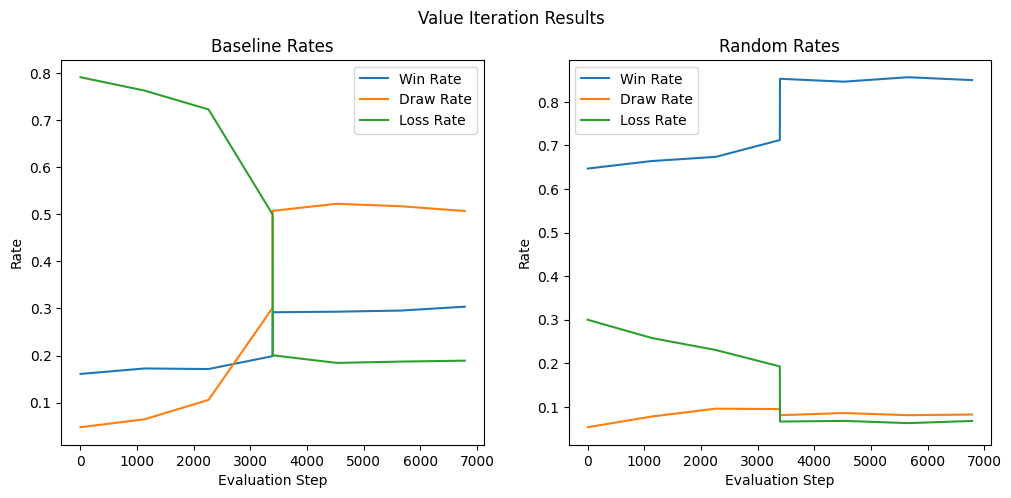

In [6]:
plot_results(all_res[0], "Value Iteration Results")

## DQN

In [7]:
dirs = ["/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/5_1_0.25_winner/q_network.pt",
        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/7_1_0.25_winner/q_network.pt",
        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/3_1_0.25_winner/q_network.pt",
        "/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/10_1_0.25_winner/q_network.pt"]

In [8]:
ns = []
ress = []
for dir in tqdm(dirs):
    n = int(dir.split("/")[-2].split("_")[0])
    x_policy = DQNPolicyWrapper(n, dir, player='X')
    o_policy = DQNPolicyWrapper(n, dir, player='O')

    baseline_results = eval_policy(n=n, x_policy=x_policy, o_policy=o_policy, opponent='baseline', runs=5000, epsilon=0.25)

    ns.append(n)
    ress.append(baseline_results)

  0%|          | 0/4 [00:00<?, ?it/s]

model loaded
model loaded


 25%|██▌       | 1/4 [00:10<00:30, 10.06s/it]

model loaded
model loaded


 50%|█████     | 2/4 [00:37<00:40, 20.37s/it]

model loaded
model loaded


 75%|███████▌  | 3/4 [00:40<00:12, 12.17s/it]

model loaded
model loaded


100%|██████████| 4/4 [02:07<00:00, 31.93s/it]


In [9]:
wrs = []
for subdict in ress:
    wrs.append(subdict['win_rate']/subdict['loss_rate'])

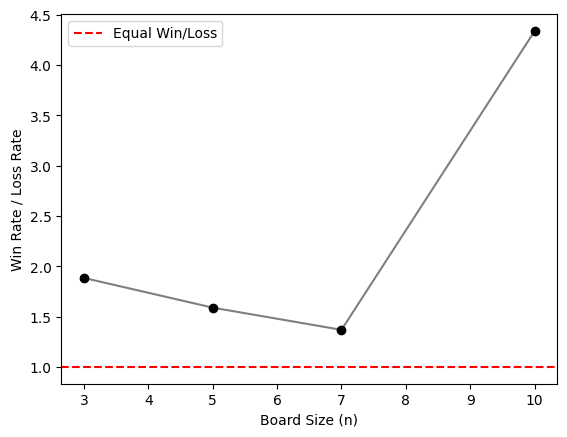

In [10]:
plt.clf()
plt.ylabel("Win Rate / Loss Rate")
plt.xlabel("Board Size (n)")
plt.axhline(y=1, color='r', linestyle='--', label='Equal Win/Loss')
plt.legend()
sorted = np.argsort(ns)
ns = np.array(ns)[sorted]
wrs = np.array(wrs)[sorted]
plt.scatter(ns,wrs,label='DQN', color='black')
plt.plot(ns,wrs,color='black',alpha=0.5)
plt.show()

In [11]:
baseline_results

{'win_rate': 0.0512, 'draw_rate': 0.937, 'loss_rate': 0.0118}

In [12]:
with open("/Users/michaelmurray/Documents/GitHub/Tic_tac_tool/Policies/DQN/3_1_0.25_winner/tracked_results.pkl", "rb") as f:
    d = pickle.load(f)

    

In [13]:
d.keys()

dict_keys(['baseline_results', 'random_results', 'iter_at_eval'])

In [14]:
d['baseline_results']

[{'win_rate': 0.3796, 'draw_rate': 0.018, 'loss_rate': 0.6024},
 {'win_rate': 0.3576, 'draw_rate': 0.023, 'loss_rate': 0.6194},
 {'win_rate': 0.2686, 'draw_rate': 0.0398, 'loss_rate': 0.6916},
 {'win_rate': 0.2676, 'draw_rate': 0.0492, 'loss_rate': 0.6832},
 {'win_rate': 0.3018, 'draw_rate': 0.0954, 'loss_rate': 0.6028},
 {'win_rate': 0.2342, 'draw_rate': 0.1836, 'loss_rate': 0.5822},
 {'win_rate': 0.2074, 'draw_rate': 0.2024, 'loss_rate': 0.5902},
 {'win_rate': 0.2426, 'draw_rate': 0.1416, 'loss_rate': 0.6158},
 {'win_rate': 0.277, 'draw_rate': 0.1268, 'loss_rate': 0.5962},
 {'win_rate': 0.2764, 'draw_rate': 0.1204, 'loss_rate': 0.6032},
 {'win_rate': 0.2814, 'draw_rate': 0.1254, 'loss_rate': 0.5932}]